In [4]:
from pathlib import Path

# Project directory
PROJECT_DIR = Path.cwd().parent

# Dataset directory
DATA_DIR = PROJECT_DIR / "data" / "raw" / "TCGA-PANCAN-HiSeq-801x20531"

print("Dataset directory:")
print(DATA_DIR)

print("\nFiles:")
for file in DATA_DIR.iterdir():
    print(file.name)

Dataset directory:
c:\Users\Ishika Jaiswal\Desktop\cancer-gene-expression-ml\data\raw\TCGA-PANCAN-HiSeq-801x20531

Files:
data.csv
labels.csv


In [5]:
# File paths
DATA_FILE = DATA_DIR / "data.csv"
LABEL_FILE = DATA_DIR / "labels.csv"

# Check file sizes
print("Expression data size:",
      round(DATA_FILE.stat().st_size / (1024**3), 2), "GB")

print("Labels file size:",
      round(LABEL_FILE.stat().st_size / (1024**2), 2), "MB")

Expression data size: 0.19 GB
Labels file size: 0.01 MB


In [6]:
with open(LABEL_FILE, "r") as f:
    print("LABELS FILE:")
    for _ in range(10):
        line = f.readline()
        if not line:
            break
        print(line.strip())

LABELS FILE:
,Class
sample_0,PRAD
sample_1,LUAD
sample_2,PRAD
sample_3,PRAD
sample_4,BRCA
sample_5,PRAD
sample_6,KIRC
sample_7,PRAD
sample_8,BRCA


In [7]:
with open(DATA_FILE, "r") as f:
    print("DATA FILE:")
    for _ in range(3):
        line = f.readline()
        if not line:
            break
        print(line[:1000].strip())

DATA FILE:
,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,gene_10,gene_11,gene_12,gene_13,gene_14,gene_15,gene_16,gene_17,gene_18,gene_19,gene_20,gene_21,gene_22,gene_23,gene_24,gene_25,gene_26,gene_27,gene_28,gene_29,gene_30,gene_31,gene_32,gene_33,gene_34,gene_35,gene_36,gene_37,gene_38,gene_39,gene_40,gene_41,gene_42,gene_43,gene_44,gene_45,gene_46,gene_47,gene_48,gene_49,gene_50,gene_51,gene_52,gene_53,gene_54,gene_55,gene_56,gene_57,gene_58,gene_59,gene_60,gene_61,gene_62,gene_63,gene_64,gene_65,gene_66,gene_67,gene_68,gene_69,gene_70,gene_71,gene_72,gene_73,gene_74,gene_75,gene_76,gene_77,gene_78,gene_79,gene_80,gene_81,gene_82,gene_83,gene_84,gene_85,gene_86,gene_87,gene_88,gene_89,gene_90,gene_91,gene_92,gene_93,gene_94,gene_95,gene_96,gene_97,gene_98,gene_99,gene_100,gene_101,gene_102,gene_103,gene_104,gene_105,gene_106,gene_107,gene_108,gene_109,gene_110,gene_111,gene_112,gene_113,gene_114,gene_115,gene_116,gene_117,gene_118,gene_119,gene_120,gene_121,

In [8]:
import pandas as pd
import numpy as np

# Load gene expression data
expression_data = pd.read_csv(DATA_FILE, index_col=0)

# Load cancer labels
labels = pd.read_csv(LABEL_FILE)

print("Expression data shape:", expression_data.shape)
print("Labels shape:", labels.shape)

print("\nExpression data:")
display(expression_data.head())

print("\nLabels:")
display(labels.head())

Expression data shape: (801, 20531)
Labels shape: (801, 2)

Expression data:


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0



Labels:


,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


today

In [9]:
# Clean and organize the labels

# Rename the label columns
labels.columns = ["sample_id", "cancer_type"]

# Check the label information
print("Cancer types:")
print(labels["cancer_type"].unique())

print("\nNumber of cancer types:", labels["cancer_type"].nunique())

print("\nClass distribution:")
print(labels["cancer_type"].value_counts())

print("\nFirst 5 labels:")
display(labels.head())

Cancer types:
['PRAD' 'LUAD' 'BRCA' 'KIRC' 'COAD']

Number of cancer types: 5

Class distribution:
cancer_type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

First 5 labels:


,sample_id,cancer_type
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


In [10]:
# Clean and organize the labels

# Rename columns
labels.columns = ["sample_id", "cancer_type"]

print("Cancer types:")
print(labels["cancer_type"].unique())

print("\nNumber of cancer types:")
print(labels["cancer_type"].nunique())

print("\nClass distribution:")
print(labels["cancer_type"].value_counts())

print("\nFirst 5 labels:")
display(labels.head())

Cancer types:
['PRAD' 'LUAD' 'BRCA' 'KIRC' 'COAD']

Number of cancer types:
5

Class distribution:
cancer_type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

First 5 labels:


,sample_id,cancer_type
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


In [11]:
# Check whether sample IDs match between expression data and labels

expression_sample_ids = expression_data.index.astype(str)
label_sample_ids = labels["sample_id"].astype(str)

print("Number of expression samples:", len(expression_sample_ids))
print("Number of label samples:", len(label_sample_ids))

print("\nAll sample IDs match:",
      expression_sample_ids.equals(label_sample_ids))

# Check for any missing or extra sample IDs
missing_in_labels = set(expression_sample_ids) - set(label_sample_ids)
missing_in_expression = set(label_sample_ids) - set(expression_sample_ids)

print("\nSamples missing from labels:", len(missing_in_labels))
print("Samples missing from expression data:", len(missing_in_expression))

Number of expression samples: 801
Number of label samples: 801

All sample IDs match: False

Samples missing from labels: 0
Samples missing from expression data: 0


In [12]:
# Check the first few sample IDs in both datasets

print("Expression data sample IDs:")
print(expression_sample_ids[:10].tolist())

print("\nLabel sample IDs:")
print(label_sample_ids[:10].tolist())

Expression data sample IDs:
['sample_0', 'sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5', 'sample_6', 'sample_7', 'sample_8', 'sample_9']

Label sample IDs:
['sample_0', 'sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5', 'sample_6', 'sample_7', 'sample_8', 'sample_9']


In [13]:
# Find positions where sample TDs differ


differences=[
    (i,expression_sample_ids[i],label_sample_ids[i])
    for i in range(len(expression_sample_ids))
    if expression_sample_ids[i]!= label_sample_ids[i]
]
print('Number of positions with different IDs:',len(differences))
print("\nFirst 10 differences:")
for difference in differences[:10]:
    print(difference)

Number of positions with different IDs: 0

First 10 differences:


In [14]:
# Check for missing values in the expression data

missing_values = expression_data.isnull().sum().sum()

print("Total missing values:", missing_values)

if missing_values == 0:
    print("No missing values found in the expression data.")
else:
    print("Missing values are present and need to be handled.")

Total missing values: 0
No missing values found in the expression data.


In [15]:
# Check data types of the expression data

print("Data types:")
print(expression_data.dtypes.value_counts())

Data types:
float64    20531
Name: count, dtype: int64


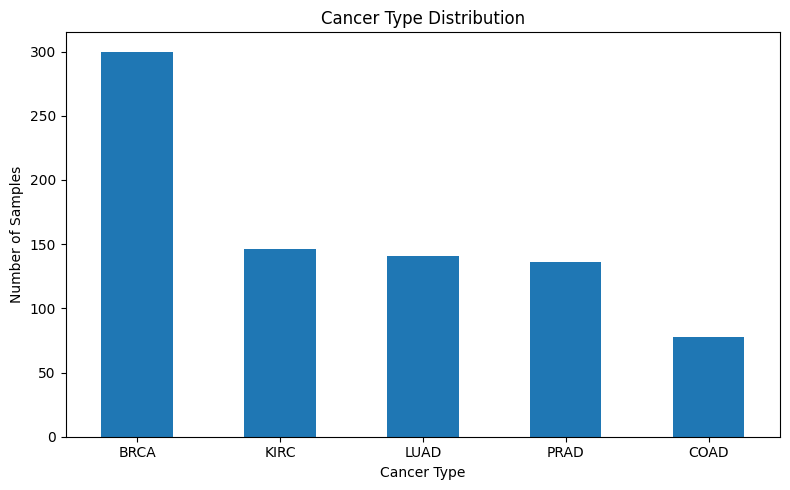

In [16]:
import matplotlib.pyplot as plt

# Count samples in each cancer type
class_counts = labels["cancer_type"].value_counts()

# Plot class distribution
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")

plt.title("Cancer Type Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# Check basic statistics of gene expression values

print("Minimum expression value:", expression_data.min().min())
print("Maximum expression value:", expression_data.max().max())
print("Mean expression value:", expression_data.mean().mean())
print("Median expression value:", expression_data.median().median())

Minimum expression value: 0.0
Maximum expression value: 20.7788287118
Mean expression value: 6.443322266573218
Median expression value: 7.5792178687


In [18]:
# Check for genes with zero variance

gene_variance = expression_data.var(axis=0)

constant_genes = (gene_variance == 0).sum()

print("Total number of genes:", expression_data.shape[1])
print("Number of constant genes:", constant_genes)
print("Number of variable genes:", (gene_variance > 0).sum())

Total number of genes: 20531
Number of constant genes: 267
Number of variable genes: 20264


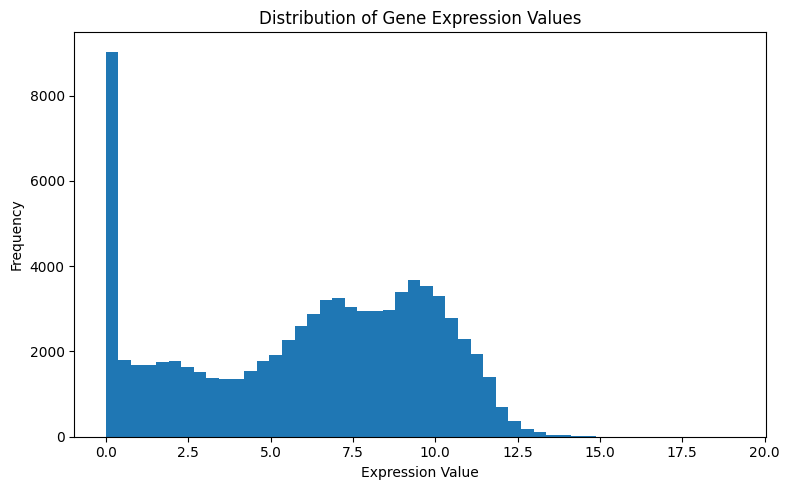

In [19]:
# Plot distribution of gene-expression values

sample_values = expression_data.sample(
    n=100,
    axis=1,
    random_state=42
).values.flatten()

plt.figure(figsize=(8, 5))
plt.hist(sample_values, bins=50)

plt.title("Distribution of Gene Expression Values")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [20]:
# separate features x and target y
x=expression_data.copy()
y=labels['cancer_type'].copy()
print('x shape:', x.shape)
print('y shape:',y.shape)
print("\nTarget classes:")
print(y.value_counts())



x shape: (801, 20531)
y shape: (801,)

Target classes:
cancer_type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split
# split data into training and testing sets
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.20,random_state=42,stratify=y)
print('Training set:',x_train.shape)
print('Testing set:',x_test.shape)
print('\nTraining class distribution:')
print(y_train.value_counts())
print('\nTesting class distribution:')
print(y_test.value_counts())

Training set: (640, 20531)
Testing set: (161, 20531)

Training class distribution:
cancer_type
BRCA    240
KIRC    116
LUAD    113
PRAD    109
COAD     62
Name: count, dtype: int64

Testing class distribution:
cancer_type
BRCA    60
KIRC    30
LUAD    28
PRAD    27
COAD    16
Name: count, dtype: int64


In [22]:
from sklearn.feature_selection import VarianceThreshold

#Identity genes with zero  variance in the training data
variance_selector = VarianceThreshold(threshold=0)
x_train_var = variance_selector.fit_transform(x_train)
x_test_var = variance_selector.transform(x_test)
print('original number of genes:',x_train.shape[1])
print ('Genes  after removing constant genes:',x_train_var.shape[1])
print('constant genes removed:',x_train.shape[1] - x_train_var.shape[1])

original number of genes: 20531
Genes  after removing constant genes: 20254
constant genes removed: 277


In [23]:
selected_genes=x_train.columns[variance_selector.get_support()]
print('number og genes retained:',len(selected_genes))
print('\nFirst 10 retained genes:')
print(selected_genes[:10].tolist())

number og genes retained: 20254

First 10 retained genes:
['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_6', 'gene_7', 'gene_8', 'gene_9', 'gene_10']


In [25]:
x_train_filtered=pd.DataFrame(
    x_train_var,columns=selected_genes,index=x_train.index
)
print('Filtered training set:',x_train_filtered.shape)

Filtered training set: (640, 20254)


In [27]:
x_test_filtered=pd.DataFrame(x_test_var,columns=selected_genes,index=x_test.index)
print('Filtered testing set:',x_test_filtered.shape)

Filtered testing set: (161, 20254)


In [30]:
from sklearn.feature_selection import SelectKBest,f_classif
#select the top 1000 genes based on ANNOVA F-test
k=1000
selector=SelectKBest(score_func=f_classif,k=k)
x_train_selected=selector.fit_transform(
    x_train_filtered,y_train
)
x_test_selected= selector.transform(x_test_filtered)
print('Original number of genes:',x_train_filtered.shape[1])
print('Number of selected genes:',x_train_selected.shape[1])
print('Training set after feature selection:',x_train_selected.shape)
print('Testing set after feature selection:',x_test_selected.shape)

Original number of genes: 20254
Number of selected genes: 1000
Training set after feature selection: (640, 1000)
Testing set after feature selection: (161, 1000)


In [31]:
selected_gene_names=x_train_filtered.columns[selector.get_support()]
print('Number of selected genes:',len(selected_gene_names))
print('\nFirst 20 selected genes:')
print(selected_gene_names[:20].tolist())


Number of selected genes: 1000

First 20 selected genes:
['gene_18', 'gene_30', 'gene_39', 'gene_88', 'gene_89', 'gene_91', 'gene_122', 'gene_134', 'gene_141', 'gene_142', 'gene_145', 'gene_148', 'gene_172', 'gene_180', 'gene_184', 'gene_197', 'gene_203', 'gene_216', 'gene_219', 'gene_220']


In [32]:
#Get the F-scores for all genes
gene_scores =pd.DataFrame({
    'gene':x_train_filtered.columns,
    'f_score':selector.scores_
})
#keep only the selected genes
selected_gene_scores=gene_scores[
    selector.get_support()
].sort_values(
    by='f_score',
    ascending=False
)
print('Top 20 selected genes by F-score:')
display(selected_gene_scores.head(20))

Top 20 selected genes by F-score:


,gene,f_score
9156,gene_9175,3836.252681
9157,gene_9176,2978.369118
218,gene_220,2704.445124
217,gene_219,2677.586717
15857,gene_15895,2652.677802
14083,gene_14114,2356.739800
17872,gene_18135,2151.056888
15860,gene_15898,1945.837851
13788,gene_13818,1944.112789
3437,gene_3439,1870.936469


# Machine -learning model

In [33]:
from sklearn.linear_model import LogisticRegression


In [34]:
logistic_model = LogisticRegression(
    max_iter=2000,random_state=42
)
logistic_model.fit(
    x_train_selected,y_train
)
print('Logistic Regression model trained successfully')

Logistic Regression model trained successfully


In [35]:
y_pred = logistic_model.predict(x_test_selected)
print('Number of predictions:',len(y_pred))
print('\nFirst 10 predictions:')
print(y_pred[:10])

Number of predictions: 161

First 10 predictions:
['KIRC' 'BRCA' 'BRCA' 'PRAD' 'KIRC' 'KIRC' 'KIRC' 'BRCA' 'BRCA' 'LUAD']


In [36]:
from sklearn.metrics import accuracy_score,f1_score
accuracy=accuracy_score(y_test,y_pred)
macro_f1=f1_score(y_test,y_pred,average='macro')
print('Logistic Regression Performance')
print('Accuracy:',round(accuracy,4))
print('Macro F1-score:',round(macro_f1,4))

Logistic Regression Performance
Accuracy: 0.9938
Macro F1-score: 0.9947


In [37]:
from sklearn.metrics import classification_report
print('Classification Report')
print(classification_report(y_test,y_pred))

Classification Report
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



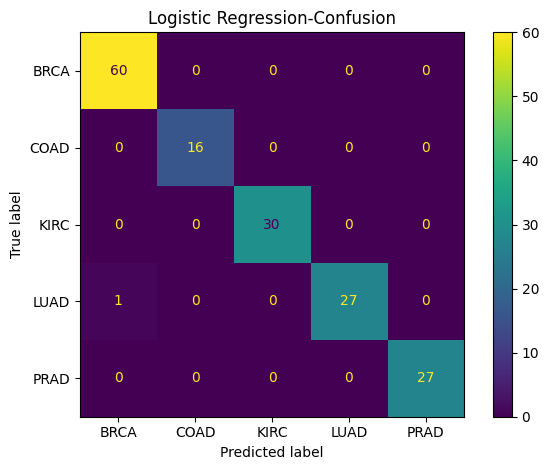

In [38]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,display_labels=logistic_model.classes_
)
disp.plot()
plt.title('Logistic Regression-Confusion')
plt.tight_layout()
plt.show()

In [39]:
from sklearn.svm import SVC

In [40]:
svm_model=SVC(kernel='linear',random_state=42)
svm_model.fit(
    x_train_selected,y_train
)
print('Linear SVM model trained ')

Linear SVM model trained 


In [41]:
y_pred_svm = svm_model.predict(x_test_selected)
print('SVM predictions generated successfully.')
print('Number of predictions:',len(y_pred_svm))
print('\nFirst 10 predictions:')
print(y_pred_svm[:10])

SVM predictions generated successfully.
Number of predictions: 161

First 10 predictions:
['KIRC' 'BRCA' 'BRCA' 'PRAD' 'KIRC' 'KIRC' 'KIRC' 'BRCA' 'BRCA' 'LUAD']


In [42]:
from sklearn.metrics import accuracy_score,f1_score
svm_accuracy = accuracy_score(y_test,y_pred_svm)
svm_macro_f1=f1_score(y_test,y_pred_svm,average='macro')

print('Linear SVM Performance Accuracy:', round(svm_accuracy,4))
print('Macro F1-score:',round(svm_macro_f1,4))

Linear SVM Performance Accuracy: 0.9938
Macro F1-score: 0.9947


# Model Comparison Table

In [43]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy
    ],
    "Macro F1": [
        macro_f1,
        svm_macro_f1
    ]
})

display(model_results)

,Model,Accuracy,Macro F1
0,Logistic Regression,0.993789,0.994711
1,Linear SVM,0.993789,0.994711


# Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    x_train_selected,
    y_train
)

print("Random Forest model trained .")

Random Forest model trained .


In [46]:
y_pred_rf = rf_model.predict(x_test_selected)

print("Random Forest predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))
print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

Random Forest predictions generated successfully.
Number of predictions: 161

First 10 predictions:
['KIRC' 'BRCA' 'BRCA' 'PRAD' 'KIRC' 'KIRC' 'KIRC' 'BRCA' 'BRCA' 'LUAD']


In [48]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")

print("Random Forest Performance Accuracy:", round(rf_accuracy, 4))
print("Macro F1-score:", round(rf_macro_f1, 4))

Random Forest Performance Accuracy: 0.9876
Macro F1-score: 0.9893


In [49]:
# update comparison table

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy,
        rf_accuracy
    ],
    "Macro F1": [
        macro_f1,
        svm_macro_f1,
        rf_macro_f1
    ]
})

display(model_results)

,Model,Accuracy,Macro F1
0,Logistic Regression,0.993789,0.994711
1,Linear SVM,0.993789,0.994711
2,Random Forest,0.987578,0.989314
